# J1 — Exploration du corpus CNC × Ultia

**Responsable** : Louis (P6) — chiffres clés pour les slides  
**Corpus** : `Dataset/data.xlsx` — 35 396 tweets, 19 mars → 1er mai 2026  
**Règle** : tout passe par `load_corpus()`, jamais de lecture directe du fichier Excel.

---
Ce notebook calcule les chiffres de référence pour les slides J1.  
Les P1-P4 font leur exploration approfondie dans leurs propres notebooks.
Les résultats finaux sont écrits dans `slides/chiffres_cles.json`.

In [3]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Style global pour toutes les figures
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'figure.figsize':   (14, 5),
    'font.size':        12,
})

from tools.corpus_loader import load_corpus
df = load_corpus('../Dataset/data.xlsx')

[load_corpus] 35,396 tweets | 2026-03-19 → 2026-05-01 | RETWEET=30,368 REPLY=3,623 QUOTE=734


## 1. Vue d'ensemble du corpus

In [4]:
print(f"Total tweets      : {len(df):,}")
print(f"Période           : {df['Date'].min().date()} → {df['Date'].max().date()}")
print(f"Comptes uniques   : {df['Author'].nunique():,}")
print(f"Comptes vérifiés  : {df['X Verified'].sum():,} ({df['X Verified'].mean():.1%})")
print()

# Distribution des types d'engagement
eng = df['Engagement Type'].value_counts()
print("Types d'engagement :")
for t, n in eng.items():
    print(f"  {t:<12} {n:>7,}  ({n/len(df):.1%})")

Total tweets      : 35,396
Période           : 2026-03-19 → 2026-05-01
Comptes uniques   : 10,437
Comptes vérifiés  : 3,234 (9.1%)

Types d'engagement :
  RETWEET       30,368  (85.8%)
  REPLY          3,623  (10.2%)
  QUOTE            734  (2.1%)
  ORIGINAL         671  (1.9%)


## 2. RT% — chiffre clé slide 3

In [5]:
pct_rt = (df['Engagement Type'] == 'RETWEET').mean()
print(f"Ratio RETWEET : {pct_rt:.1%}")
print()
print("Interprétation :")
if pct_rt > 0.80:
    print("  → Amplification massive — plus de 80% des tweets sont des retweets.")
    print("    La crise se propage par relay, pas par opinion originale.")
elif pct_rt > 0.60:
    print("  → Amplification forte — la dynamique est portée par la diffusion.")
else:
    print("  → Engagement plus varié — opinions originales significatives.")

Ratio RETWEET : 85.8%

Interprétation :
  → Amplification massive — plus de 80% des tweets sont des retweets.
    La crise se propage par relay, pas par opinion originale.


## 3. Timeline — volume journalier et pic de crise

Pic : 2026-03-27 — 7,303 tweets


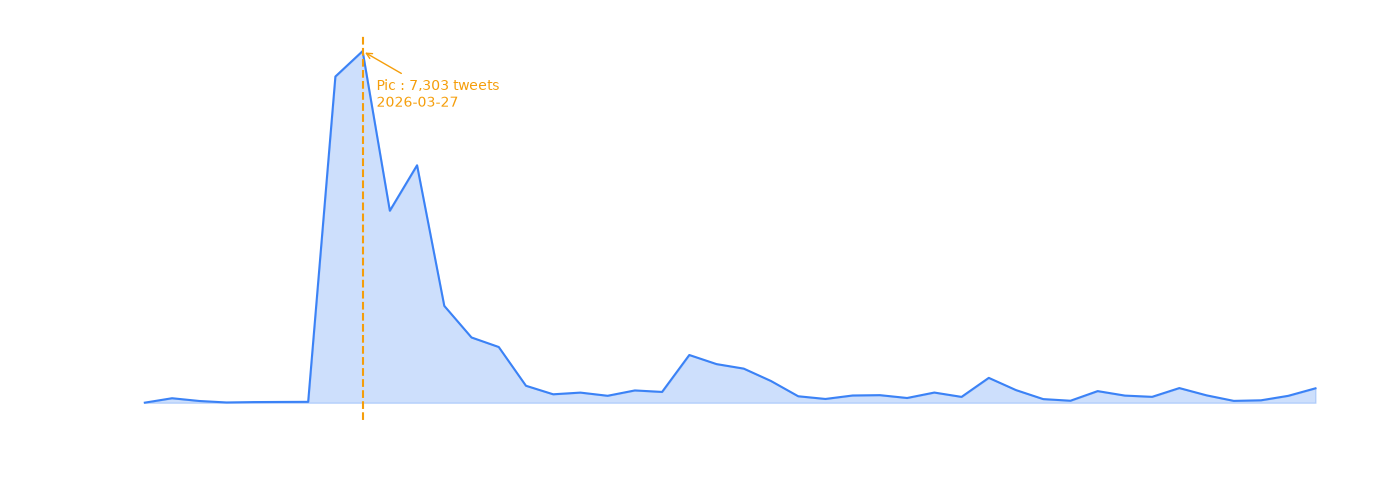

Sauvegardé → slides/figures/fig_timeline.png


In [7]:
df['_day'] = df['Date'].dt.date
daily = df.groupby('_day').size().rename('count')

peak_day   = daily.idxmax()
peak_vol   = int(daily.max())
print(f"Pic : {peak_day} — {peak_vol:,} tweets")

# Figure timeline
fig, ax = plt.subplots()
ax.fill_between(pd.to_datetime(daily.index), daily.values, alpha=0.25, color='#3b82f6')
ax.plot(pd.to_datetime(daily.index), daily.values, color='#3b82f6', linewidth=1.5)

# Annotation pic
ax.axvline(pd.Timestamp(peak_day), color='#f59e0b', linewidth=1.5, linestyle='--')
ax.annotate(
    f'Pic : {peak_vol:,} tweets\n{peak_day}',
    xy=(pd.Timestamp(peak_day), peak_vol),
    xytext=(10, -40), textcoords='offset points',
    fontsize=10, color='#f59e0b',
    arrowprops=dict(arrowstyle='->', color='#f59e0b')
)

ax.set_title('Volume de tweets par jour — Affaire CNC × Ultia', fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Tweets / jour')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0))
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('../../slides/figures/fig_timeline.png', dpi=150, bbox_inches='tight')
plt.show()
print('Sauvegardé → slides/figures/fig_timeline.png')

## 4. Distribution des sentiments

Distribution sentiment :
  neutral     23,476  (66.3%)
  negative    10,861  (30.7%)
  positive     1,059  (3.0%)

Taux de négativité : 30.7%


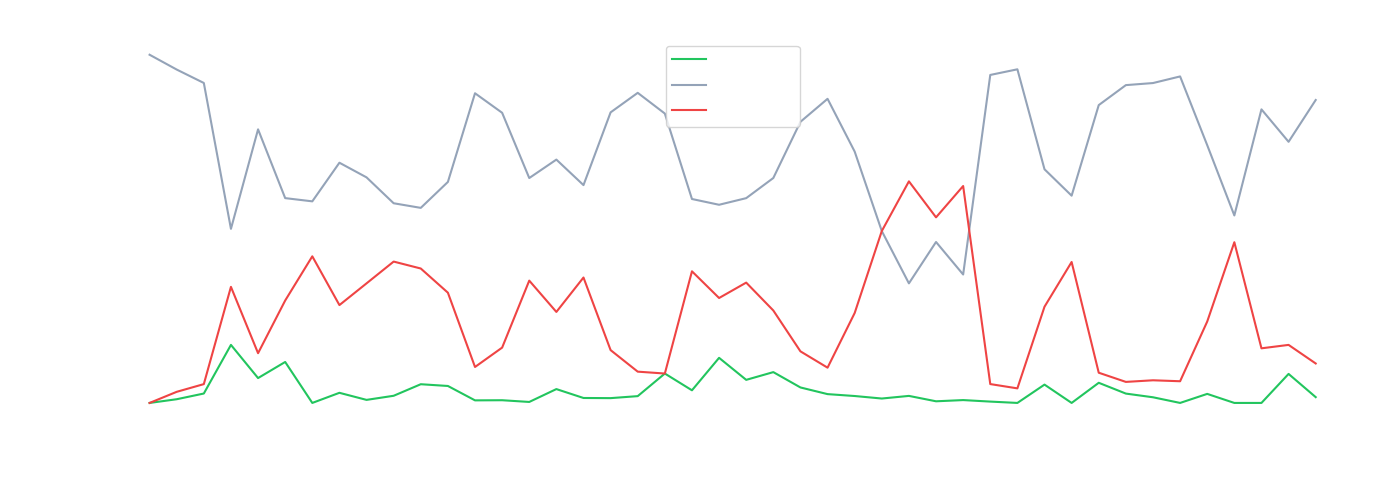

In [9]:
sent = df['Sentiment'].value_counts()
print("Distribution sentiment :")
for s, n in sent.items():
    print(f"  {s:<10} {n:>7,}  ({n/len(df):.1%})")

pct_neg = sent.get('negative', 0) / len(df)
print(f"\nTaux de négativité : {pct_neg:.1%}")

# Évolution sentiment par jour
sent_daily = (
    df.groupby(['_day', 'Sentiment'])
    .size().unstack(fill_value=0)
    .apply(lambda r: r / r.sum(), axis=1)
)

colors = {'negative': '#ef4444', 'neutral': '#94a3b8', 'positive': '#22c55e'}
fig, ax = plt.subplots()
for col in ['positive', 'neutral', 'negative']:
    if col in sent_daily.columns:
        ax.plot(pd.to_datetime(sent_daily.index), sent_daily[col],
                label=col, color=colors.get(col, 'grey'), linewidth=1.5)

ax.set_title('Évolution du sentiment par jour', fontweight='bold')
ax.set_ylabel('Part des tweets (%)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0))
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('../../slides/figures/fig_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Mise à jour de chiffres_cles.json

In [11]:
json_path = '../../slides/chiffres_cles.json'
with open(json_path) as f:
    chiffres = json.load(f)

# Chiffres calculés dans ce notebook
chiffres['volume_total']       = len(df)
chiffres['periode_debut']      = str(df['Date'].min().date())
chiffres['periode_fin']        = str(df['Date'].max().date())
chiffres['pic_date']           = str(peak_day)
chiffres['pic_volume_jour']    = peak_vol
chiffres['pct_retweets']       = round(float(pct_rt), 4)
chiffres['pct_negatif']        = round(float(pct_neg), 4)
chiffres['nb_comptes_uniques'] = int(df['Author'].nunique())
chiffres['pct_comptes_verified'] = round(float(df['X Verified'].mean()), 4)

with open(json_path, 'w') as f:
    json.dump(chiffres, f, indent=2, ensure_ascii=False)

print('chiffres_cles.json mis à jour :')
for k, v in chiffres.items():
    if not k.startswith('_'):
        print(f'  {k:<30} {v}')

chiffres_cles.json mis à jour :
  volume_total                   35396
  periode_debut                  2026-03-19
  periode_fin                    2026-05-01
  pic_date                       2026-03-27
  pic_volume_jour                7303
  pct_retweets                   0.858
  narratif_dominant              Extrême Droite / Politique
  pct_negatif                    0.3068
  top_acteur_type                None
  nb_comptes_uniques             10437
  pct_comptes_verified           0.0914
  note_coordination              None
  terme_dominant                 #vachealait
  engagement_negatif_moyen       20.3
  narratif_extreme_droite        15261
  narratif_copinage              12441
  narratif_defense_ultia         3893
  narratif_censure               248
